In [3]:
pip install pykalman


   ---------------------------------------- 0/2 [scikit-base]
   ---------------------------------------- 0/2 [scikit-base]
   ---------------------------------------- 0/2 [scikit-base]
   ---------------------------------------- 0/2 [scikit-base]
   ---------------------------------------- 0/2 [scikit-base]
   ---------------------------------------- 0/2 [scikit-base]
   ---------------------------------------- 0/2 [scikit-base]
   ---------------------------------------- 0/2 [scikit-base]
   -------------------- ------------------- 1/2 [pykalman]
   -------------------- ------------------- 1/2 [pykalman]
   -------------------- ------------------- 1/2 [pykalman]
   ---------------------------------------- 2/2 [pykalman]

Note: you may need to restart the kernel to use updated packages.


In [55]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pykalman import KalmanFilter

In [9]:
tau = 0.1
g = 9.81 # m/s^2
times = np.arange(40)
v0 = 20 # Initial velocity in m/s
h0 = 1 # Initial height in m

# True Trajectory = -0.5 * g * t^2
Actual_trajectory = h0 + (v0*times*tau) - 0.5*g*(times*tau)**2

#Simuluate the noisy camera data (Variance = 3, so Std Dev = sqrt(3))
sim = Actual_trajectory + np.sqrt(3) * np.random.randn(len(times)) # Simulated trajectory with noise

In [50]:
kf = KalmanFilter(n_dim_obs=1, n_dim_state=2, 
                  initial_state_mean=[0, 0], 
                  initial_state_covariance=np.eye(2)*20, 
                  transition_matrices=[[1, tau], [0, 1]], 
                  observation_matrices=[[1, 0]], 
                  observation_covariance=3,
                  transition_covariance = np.zeros((2, 2)),
                  transition_offsets = [-0.5*g*tau**2, -g*tau])

In [51]:
state_means, state_covs = kf.filter(sim)

estimated_position = state_means[:, 0]

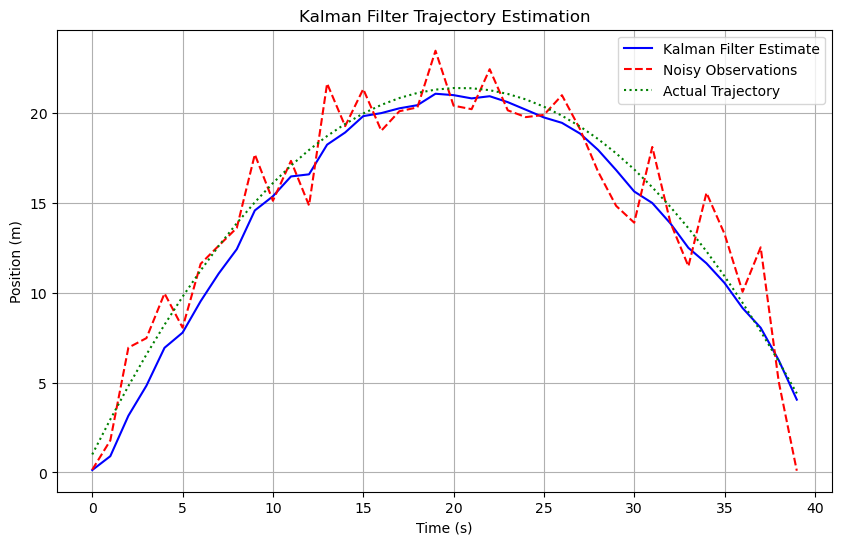

In [52]:
plt.figure(figsize=(10, 6))

plt.plot(times, estimated_position, label='Kalman Filter Estimate', color='blue')
plt.plot(times, sim, label='Noisy Observations', color='red', linestyle='dashed')
plt.plot(times, Actual_trajectory, label='Actual Trajectory', color='green', linestyle='dotted')
plt.title('Kalman Filter Trajectory Estimation')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.legend()
plt.grid()
plt.show()

From simple rolling averages to state-space modeling, the core objective remains the same: updating an estimate based on new, noisy market data. The evolution of these filters is fundamentally about upgrading the "gain" (the weight applied to new data) from a shrinking fraction, to a constant, and finally to a dynamic matrix.

### 1. The Recursive Simple Moving Average (SMA)
The SMA assigns an equal weight to all historical data points. Written recursively, the gain applied to the new measurement is simply $1/k$. As time goes on, the gain shrinks toward zero, making the filter unresponsive to new market data.

**The Math:**
$$\hat{x}_k = \hat{x}_{k-1} + \frac{1}{k}(z_k - \hat{x}_{k-1})$$


### 2. The Exponential Moving Average (EMA)
To prevent the gain from shrinking to zero, we replace $1/k$ with a constant smoothing factor, $\alpha$. This creates a low-pass filter (EWMA), heavily used in quantitative finance for baseline volatility forecasting. However, because $\alpha$ is a fixed constant, the filter cannot adapt to changing signal-to-noise ratios, such as a sudden volatility spike.

**The Math:**
$$\hat{x}_k = \hat{x}_{k-1} + \alpha(z_k - \hat{x}_{k-1})$$





### 3. The State-Space Kalman Filter
The Kalman Filter replaces the constant $\alpha$ with a dynamic **Kalman Gain ($K_k$)** in a multidimensional matrix environment. 

In a quantitative context, we model the market as a hidden stochastic process:
* **$x_k$ (Latent State):** The true hidden variable we want to track (e.g., the true trend, or fair-value spread).
* **$F_k$ (State Transition):** How the state naturally evolves (e.g., an identity matrix for a random walk).
* **$B_k u_k$ (Control Input):** A known, deterministic driver. (e.g, thrust applied when engaging in aircraft control OR long-term average of mean-reverting asset like the VIX)
* **$w_k$ (Process Noise):** The stochastic shock to the system architecture (e.g., a macroeconomic regime shift), governed by the covariance matrix $Q$.
* **$H_k$ (Observation Matrix):** The Matrix that multiplies hidden state to calculate what the actual "trajectory" is.

**The State & Observation Equations:**
$$x_k = F_k x_{k-1} + B_k u_k + w_k$$
$$z_k = H_k x_k + v_k$$

**The Predict-Correct Loop:**
$$\text{Predict State: } \hat{x}_{k|k-1} = F_k \hat{x}_{k-1|k-1} + B_k u_k$$
$$\downarrow$$
$$\text{Predict Covariance: } P_{k|k-1} = F_k P_{k-1|k-1} F_k^T + Q_k$$
$$\downarrow$$
$$\text{Kalman Gain: } K_k = P_{k|k-1} H_k^T (H_k P_{k|k-1} H_k^T + R_k)^{-1}$$
$$\downarrow$$
$$\text{Update State: } \hat{x}_{k|k} = \hat{x}_{k|k-1} + K_k (z_k - H_k \hat{x}_{k|k-1})$$
$$\downarrow$$
$$\text{Update Covariance: } P_{k|k} = (I - K_k H_k) P_{k|k-1}$$


In [154]:
import yfinance as yf
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import pandas_datareader.data as web
from pykalman import KalmanFilter
import statsmodels.api as sm

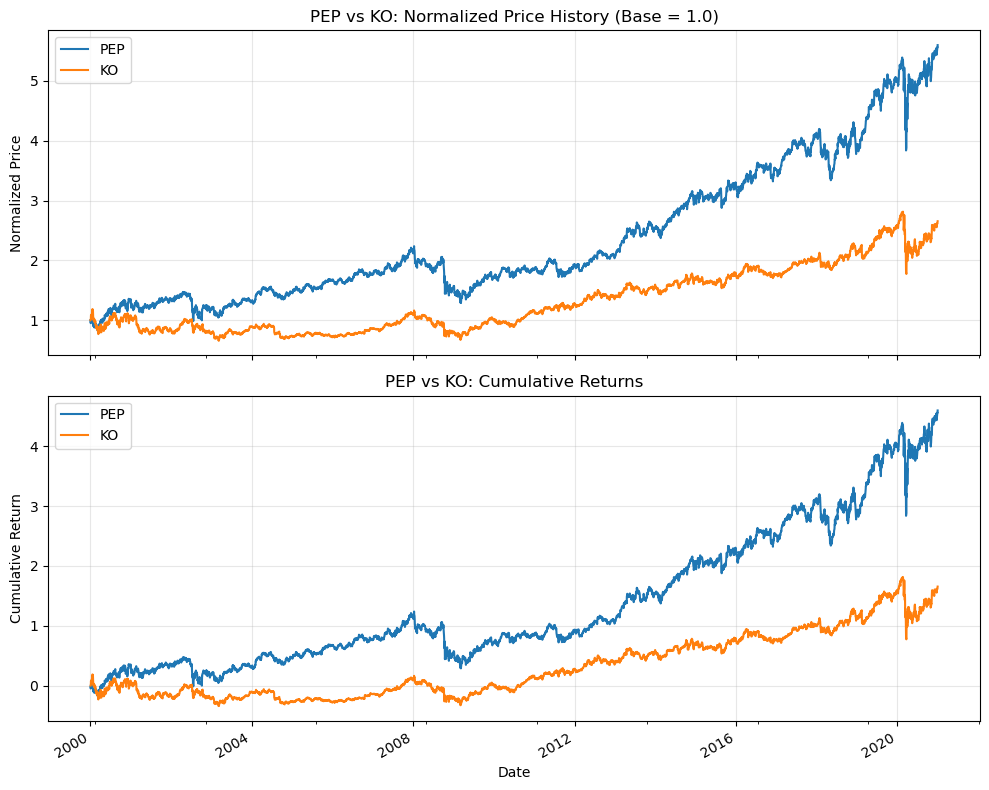

In [176]:
import pandas_datareader.data as web
import pandas as pd
import matplotlib.pyplot as plt

# 1. Fetch and align data
df_pep = web.DataReader('PEP', data_source='stooq', start='2000-01-01', end='2020-12-31').sort_index()
df_ko = web.DataReader('KO', data_source='stooq', start='2000-01-01', end='2020-12-31').sort_index()

data = pd.DataFrame({'PEP': df_pep['Close'], 'KO': df_ko['Close']}).dropna()

normalized_prices = data / data.iloc[0]

# 3. Calculate Cumulative Returns
# (1 + daily_returns).cumprod() - 1
cumulative_returns = (1 + data.pct_change().dropna()).cumprod() - 1

# 4. Plotting
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)

# Top Subplot: Normalized Prices
normalized_prices.plot(ax=axes[0], title='PEP vs KO: Normalized Price History (Base = 1.0)')
axes[0].set_ylabel("Normalized Price")
axes[0].grid(True, alpha=0.3)

# Bottom Subplot: Cumulative Returns
cumulative_returns.plot(ax=axes[1], title='PEP vs KO: Cumulative Returns')
axes[1].set_ylabel("Cumulative Return")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [163]:
x = list(np.log(data['PEP']))
x_const = sm.add_constant(x)
y = list(np.log(data['KO']))
linear_reg = sm.OLS(y, x_const).fit()
linear_reg.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                 3.493e+04
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:17:18   Log-Likelihood:                 2871.2
No. Observations:                5284   AIC:                            -5738.
Df Residuals:                    5282   BIC:                            -5725.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0066      0.017     -0.385      0.700      -0.040       0.027
x1             0.7958      0.004    186.899      0.000       0.787       0.804
==============================================================================
Omnibus:                       69.373   Durbin-Watson:                   0.006
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              101.215
Skew:                           0.149   Prob(JB):                     1.05e-22
Kurtosis:                       3.609   Cond. No.                         37.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [159]:
beta = linear_reg.params[1]
alpha = linear_reg.params[0]    
y_pred = np.log(data['PEP']) * beta + alpha

C:\Users\2115h\AppData\Local\Temp\ipykernel_78876\4204125446.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cb.ax.set_yticklabels([str(p) for p in data['PEP'].index])


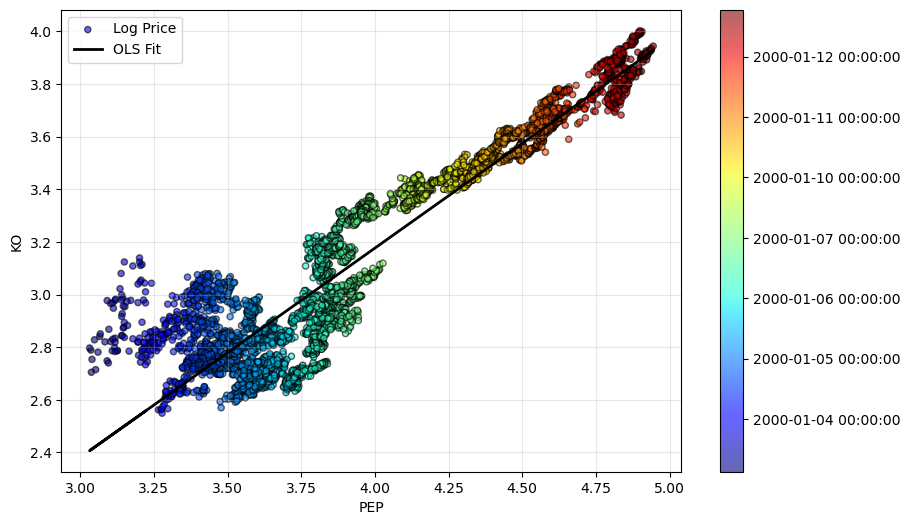

In [178]:
plt.figure(figsize =(10,6))
cm = plt.get_cmap('jet')
sc = plt.scatter(np.log(data['PEP']), np.log(data['KO']), s=20, c=x, cmap=cm, marker='o',
                 alpha=0.6,label='Log Price',edgecolor='k')
plt.plot(x, y_pred, '-',c='black',linewidth=2, label='OLS Fit')
plt.legend()
cb = plt.colorbar(sc)
cb.ax.set_yticklabels([str(p) for p in data['PEP'].index])
plt.xlabel('PEP')
plt.ylabel('KO')
plt.grid(True, alpha=0.3)

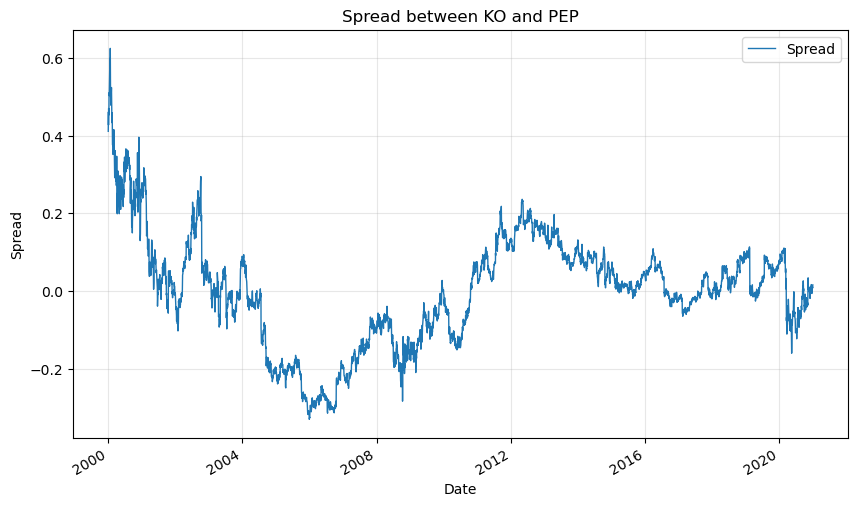

In [228]:
df = pd.DataFrame(np.log(data['KO']) - np.log(data['PEP']) * beta - alpha, index=data['PEP'].index)
df.columns = ['Spread']
df.plot(title='Spread between KO and PEP', figsize=(10,6), linewidth=1)
plt.ylabel('Spread')
plt.grid(True, alpha=0.3)

<Axes: title={'center': 'Spread with Mean and Bands'}, xlabel='Date'>

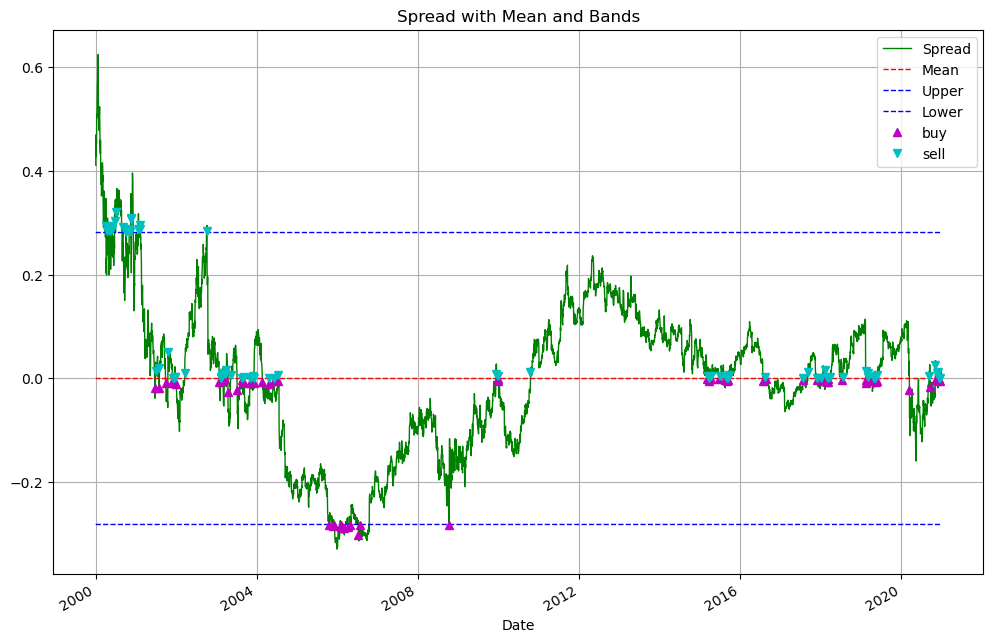

In [229]:
df['Mean'] = df['Spread'].mean()
df['Upper'] = df['Mean'] + 2*df['Spread'].std()
df['Lower'] = df['Mean'] - 2*df['Spread'].std()
df['buy'] = df['Spread'][((df['Spread'] < df['Lower']) & (df['Spread'].shift(1) > df['Lower']) | 
                          (df['Spread'] <  df['Mean']) & (df['Spread'].shift(1) >  df['Mean']))]

df['sell'] = df['Spread'][((df['Spread'] > df['Upper']) & (df['Spread'].shift(1) < df['Upper']) | 
                           (df['Spread'] >  df['Mean']) & (df['Spread'].shift(1) <  df['Mean']))]
df.plot(title='Spread with Mean and Bands',figsize =(12,8), style=['g', '--r', '--b', '--b', 'm^','cv'], grid=True, linewidth=1)

In [246]:
observation_mat = sm.add_constant(np.log(data['PEP']).values)[:,np.newaxis]
delta = 1e-5
trans_cov = delta / (1 - delta) * np.eye(2)

In [247]:
kf = KalmanFilter(
    n_dim_obs=1,
    n_dim_state=2,
    initial_state_mean=np.zeros(2),
    initial_state_covariance=np.ones((2, 2)),
    transition_matrices=np.eye(2),
    observation_matrices=observation_mat,
    observation_covariance=1.0,
    transition_covariance=trans_cov
)

C:\Users\2115h\AppData\Local\Temp\ipykernel_78876\508663791.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cb.ax.set_yticklabels([str(p) for p in data['PEP'].index])


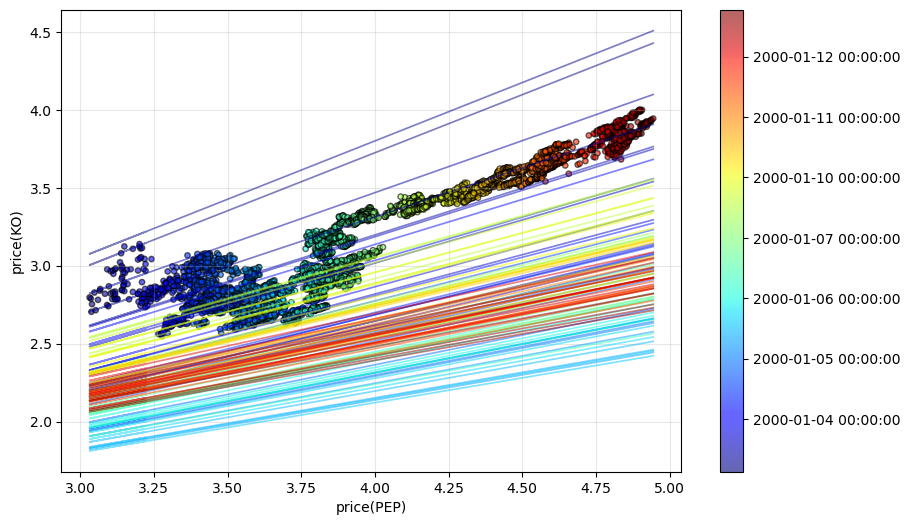

In [248]:
plt.figure(figsize=(10,6))
plt.grid(True, alpha=0.3)
cm = plt.get_cmap('jet')
sc = plt.scatter(np.log(data['PEP']), np.log(data['KO']), s=15, c=x, cmap=cm, marker='o',
                 alpha=0.6,label='Log Price',edgecolor='k')
cb= plt.colorbar(sc)
cb.ax.set_yticklabels([str(p) for p in data['PEP'].index])
plt.xlabel('price(PEP)')
plt.ylabel('price(KO)')
step = 50
colors_1 = np.linspace(0, 1, len(state_means[: : step]))
for i, b in enumerate(state_means[: : step]):
    plt.plot(np.log(data['PEP']), b[0] * np.log(data['PEP']) + b[1], color=cm(colors_1[i]), alpha=0.5, lw=1.25)


In [251]:
state_means, state_covs = kf.filter(np.log(data['KO']).values[:, np.newaxis])

In [255]:
kl_spread = np.log(data['KO']) - (np.log(data['PEP']) * state_means[:,1]) - state_means[:,0]
df['kl_spread'] = kl_spread

In [240]:
print("Column 0:", state_means[-1, 0])
print("Column 1:", state_means[-1, 1])

Column 0: 0.35947985974800994
Column 1: 1.0400626954218188


<Axes: xlabel='Date'>

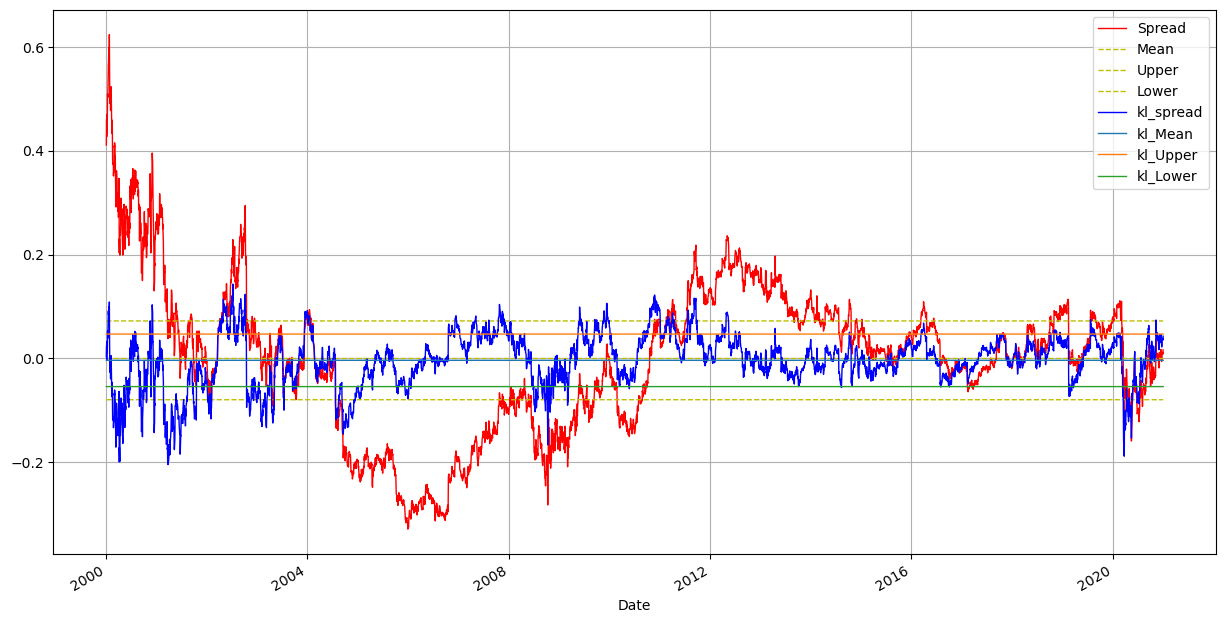

In [274]:
new_df = df.drop(['buy','sell'], axis=1)
new_df['kl_Mean'] = new_df['kl_spread'].mean()
new_df['kl_Upper'] = new_df['kl_Mean'] + 1 * new_df['kl_spread'].std()
new_df['kl_Lower'] = new_df['kl_Mean'] - 1 * new_df['kl_spread'].std()
new_df.plot(figsize =(15,8),style=['r','--y', '--y', '--y','b'],grid=True, linewidth=1)

In [275]:
new_df['kl_Mean'] = new_df['kl_spread'].mean()
new_df['kl_Upper'] = new_df['kl_Mean'] + 1 * new_df['kl_spread'].std()
new_df['kl_Lower'] = new_df['kl_Mean'] - 1 * new_df['kl_spread'].std()

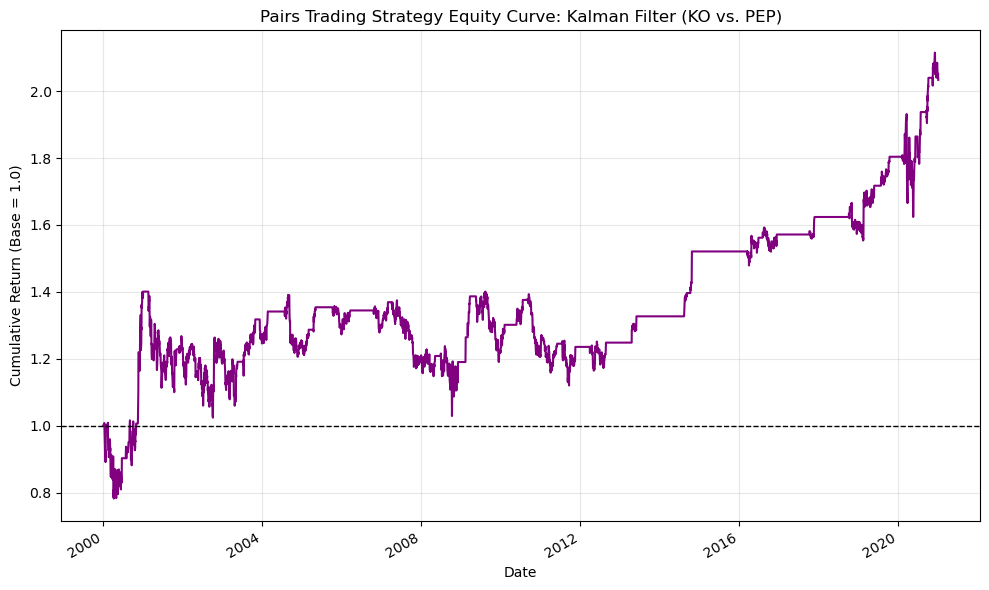

In [276]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Generate Trading Signals & Positions
# ---------------------------------------------------------
new_df['Position'] = np.nan

# Entry Signals
new_df.loc[new_df['kl_spread'] < new_df['kl_Lower'], 'Position'] = 1  # Long the Spread
new_df.loc[new_df['kl_spread'] > new_df['kl_Upper'], 'Position'] = -1 # Short the Spread

# Exit Signals (Crossing the Mean)
# If spread crosses above mean while long, or below mean while short, exit to 0
new_df.loc[(new_df['kl_spread'] >= new_df['kl_Mean']) & (new_df['kl_spread'].shift(1) < new_df['kl_Mean']), 'Position'] = 0
new_df.loc[(new_df['kl_spread'] <= new_df['kl_Mean']) & (new_df['kl_spread'].shift(1) > new_df['kl_Mean']), 'Position'] = 0

# Forward fill the positions so we hold trades between signals, then fill rest with 0
new_df['Position'] = new_df['Position'].ffill().fillna(0)

# ---------------------------------------------------------
# 2. Calculate Strategy Returns
# ---------------------------------------------------------
# Calculate daily percentage returns for the underlying assets
ret_KO = data['KO'].pct_change()
ret_PEP = data['PEP'].pct_change()

# Retrieve the dynamic Kalman Beta (state_means[:, 1]) calculated earlier
# We format it as a series to align with our dataframe index
rolling_beta = pd.Series(state_means[:, 1], index=data.index)

# Calculate Daily PnL
# Portfolio Return = Position * (Return of Y - Beta * Return of X)
# CRITICAL: We shift Position and Beta by 1 day (shift(1)) to prevent look-ahead bias. 
# This simulates seeing the signal at today's close, and earning tomorrow's return.
daily_strategy_return = new_df['Position'].shift(1) * (ret_KO - (rolling_beta.shift(1) * ret_PEP))

# ---------------------------------------------------------
# 3. Calculate and Plot the Equity Curve
# ---------------------------------------------------------
# Calculate cumulative compounding returns
new_df['Equity_Curve'] = (1 + daily_strategy_return.fillna(0)).cumprod()

# Plot the Equity Curve
plt.figure(figsize=(10, 6))
new_df['Equity_Curve'].plot(color='purple', linewidth=1.5)

plt.title('Pairs Trading Strategy Equity Curve: Kalman Filter (KO vs. PEP)')
plt.ylabel('Cumulative Return (Base = 1.0)')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.axhline(1.0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

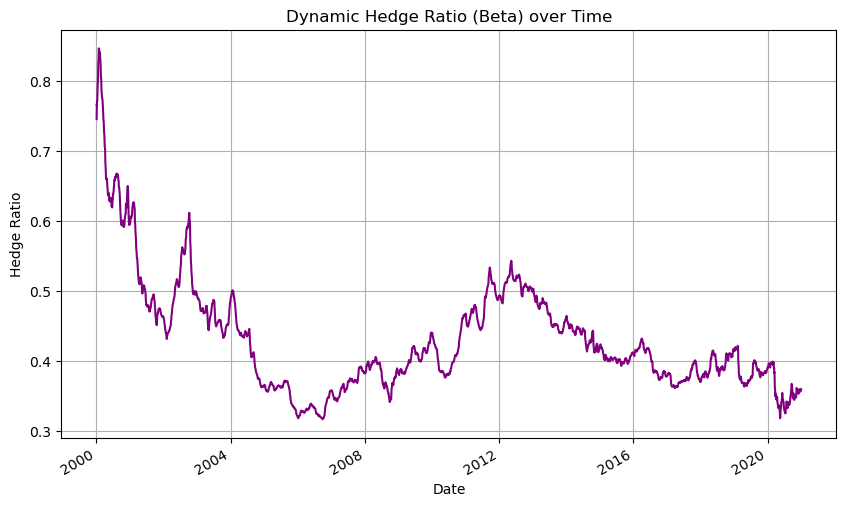

In [162]:
# Construct the observation matrix.
# We add a column of 1s to KO's prices to estimate the intercept (alpha).
obs_mat = np.vstack([data['PEP'].values, np.ones(len(data))]).T[:, np.newaxis]

# Initialize the Kalman Filter
# delta controls the speed of adaptation of the filter. Lower = slower adaptation.




# Run the filter to estimate the hidden states (beta and alpha)
state_means, state_covs = kf.filter(data['KO'].values)

# Extract the dynamic hedge ratio (beta) and intercept (alpha)
data['beta'] = state_means[:, 0]
data['alpha'] = state_means[:, 1]

# Plot the dynamic hedge ratio
data['beta'].plot(figsize=(10, 6), title="Dynamic Hedge Ratio (Beta) over Time", color='purple')
plt.ylabel("Hedge Ratio")
plt.grid(True)
plt.show()

In [279]:
import numpy as np
import pandas as pd
import pandas_datareader.data as web
from pykalman import KalmanFilter
import matplotlib.pyplot as plt

# ==========================================
# 1. DATA COLLECTION & PREPARATION
# ==========================================
print("Fetching data...")
df_pep = web.DataReader('PEP', 'stooq', '2000-01-01', '2026-01-01')
df_ko  = web.DataReader('KO', 'stooq', '2000-01-01', '2026-01-01')

# Store raw prices for Section 6 portfolio math
data = pd.DataFrame({
    'PEP_Raw': df_pep['Close'], 
    'KO_Raw': df_ko['Close']
}).dropna().sort_index()

# Convert to Log Prices for the Kalman Filter to prevent magnitude drift
data['PEP'] = np.log(data['PEP_Raw'])
data['KO'] = np.log(data['KO_Raw'])

# ==========================================
# 2. KALMAN FILTER SETUP (STATE SPACE)
# ==========================================
print("Initializing state-space model...")

trans_cov = np.eye(2) * 1e-8
obs_var = 1e-5

kf = KalmanFilter(
    n_dim_obs=1, n_dim_state=2,
    initial_state_mean=[0.0, 0.0],
    initial_state_covariance=np.ones((2, 2)),
    transition_matrices=np.eye(2),
    transition_covariance=trans_cov,
    observation_covariance=obs_var
)

# Initialize states
state_mean = np.zeros(2)
state_cov = np.ones((2, 2)) *50

# Storage arrays
beta_history = np.zeros(len(data))
alpha_history = np.zeros(len(data))
predictions = np.zeros(len(data))
variances = np.zeros(len(data))

# ==========================================
# 3. PURE KALMAN FILTER (STEP-BY-STEP)
# ==========================================
print("Filtering latent states...")
for t in range(len(data)):
    # 1. A Priori State Prediction
    x_prior = state_mean
    P_prior = state_cov + trans_cov
    
    # 2. Observation matrix H_t = [PEP_Log_t, 1]
    H_t = np.array([[data['PEP'].iloc[t], 1.0]])
    
    # 3. Predict today's KO Log price
    y_hat = np.dot(H_t, x_prior)[0]
    predictions[t] = y_hat
    
    # 4. Calculate exact Innovation Variance for the Z-Score
    S_t = np.dot(np.dot(H_t, P_prior), H_t.T)[0, 0] + obs_var
    variances[t] = S_t
    
    # 5. Observe true KO Log price and update state (A Posteriori)
    y_t = data['KO'].iloc[t]
    
    state_mean, state_cov = kf.filter_update(
        filtered_state_mean=state_mean,
        filtered_state_covariance=state_cov,
        observation=y_t,
        observation_matrix=H_t
    )
    
    beta_history[t] = state_mean[0]
    alpha_history[t] = state_mean[1]

data['beta'] = beta_history
data['alpha'] = alpha_history

# Spread is the prediction error of the Log prices
data['Spread'] = data['KO'] - predictions
data['Kalman_Variance'] = variances
data['Native_Z_Score'] = data['Spread'] / np.sqrt(data['Kalman_Variance'])
data.loc[data.index[:30], 'Native_Z_Score'] = np.nan  # Avoid unreliable Z-scores in the initial period

# ==========================================
# 4. SECONDARY REGRESSIONS (REMOVED)
# ==========================================
# ADF and OU half-life removed to prevent system conflict. 
# We trust the Kalman Filter to govern cointegration.

# ==========================================
# 5. ASYMMETRIC TRADING LOGIC (CIRCUIT BREAKERS)
# ==========================================
print("Evaluating execution thresholds...")

# Tuned for a single highly-cointegrated pair
ENTRY_THRESHOLD = 1.0  
EXIT_THRESHOLD = 0.0

# THE KILL SWITCH: If the spread blows out beyond 3.5 SDs, the fundamental 
# cointegration is broken. We must cut the trade and take the localized loss 
# rather than riding it to -10 SDs.
STRUCTURAL_BREAK = 3.5  

positions = np.zeros(len(data))
current_pos = 0

z_scores = data['Native_Z_Score'].values

for i in range(len(data)):
    z = z_scores[i]
    
    if pd.isna(z):
        continue
        
    if current_pos == 0:
        # Standard Entry (Only enter if the spread isn't already blowing out)
        if z < -ENTRY_THRESHOLD and z > -STRUCTURAL_BREAK:
            current_pos = 1   # Long KO / Short PEP
        elif z > ENTRY_THRESHOLD and z < STRUCTURAL_BREAK:
            current_pos = -1  # Short KO / Long PEP
            
    elif current_pos == 1:
        # Long Exit Logic
        if z >= EXIT_THRESHOLD:
            current_pos = 0   # Target Reached: Profitable mean-reversion
        elif z <= -STRUCTURAL_BREAK:
            current_pos = 0   # CIRCUIT BREAKER: Regime shift, cut losses
            
    elif current_pos == -1:
        # Short Exit Logic
        if z <= EXIT_THRESHOLD:
            current_pos = 0   # Target Reached: Profitable mean-reversion
        elif z >= STRUCTURAL_BREAK:
            current_pos = 0   # CIRCUIT BREAKER: Regime shift, cut losses
            
    positions[i] = current_pos

data['Target_Position'] = pd.Series(positions, index=data.index).shift(1).fillna(0)

# ==========================================
# 6. VOLATILITY-TARGETED PORTFOLIO RETURNS
# ==========================================
print("Aggregating levered portfolio returns...")

# 1. Raw daily returns using actual dollars
data['Ret_KO'] = data['KO_Raw'].pct_change()
data['Ret_PEP'] = data['PEP_Raw'].pct_change()

# 2. Portfolio Weights (Log Beta = Dollar Elasticity)
total_weight = 1.0 + np.abs(data['beta'])
data['W_KO'] = data['Target_Position'] * (1.0 / total_weight)
data['W_PEP'] = data['Target_Position'] * (-data['beta'] / total_weight)

data['Raw_Strategy_Return'] = data['W_KO'] * data['Ret_KO'] + data['W_PEP'] * data['Ret_PEP']

# 3. Dynamic Volatility Targeting
TARGET_ANNUAL_VOL = 0.15  
MAX_LEVERAGE = 5.0        
VOL_LOOKBACK = 60         

# Calculate rolling vol, handling the periods where the strategy sits in cash safely
rolling_vol = data['Raw_Strategy_Return'].rolling(window=VOL_LOOKBACK, min_periods=20).std() * np.sqrt(252)
rolling_vol = rolling_vol.replace(0.0, np.nan)

raw_leverage = TARGET_ANNUAL_VOL / rolling_vol
data['Leverage'] = raw_leverage.shift(1).clip(lower=0.0, upper=MAX_LEVERAGE).fillna(1.0)

# 4. Levered Equity Curve
data['Levered_Return'] = data['Raw_Strategy_Return'] * data['Leverage']
data['Levered_Equity_Curve'] = (1 + data['Levered_Return'].fillna(0)).cumprod()
data['Benchmark_Equity'] = (1 + data['Ret_KO'].fillna(0)).cumprod()

print("\nSimulation Complete. Final Metrics:")
print(data[['Target_Position', 'Raw_Strategy_Return', 'Leverage', 'Levered_Equity_Curve']].tail(10))

Fetching data...
Initializing state-space model...
Filtering latent states...
Evaluating execution thresholds...
Aggregating levered portfolio returns...

Simulation Complete. Final Metrics:
            Target_Position  Raw_Strategy_Return  Leverage  \
Date                                                         
2025-12-17              0.0             0.000000  1.748654   
2025-12-18              1.0            -0.000579  1.750007   
2025-12-19              1.0             0.000900  1.755124   
2025-12-22              1.0             0.004376  1.757540   
2025-12-23              0.0             0.000000  1.759461   
2025-12-24              0.0             0.000000  1.766889   
2025-12-26              0.0            -0.000000  1.767914   
2025-12-29             -1.0            -0.001078  1.767914   
2025-12-30             -1.0             0.000514  1.774496   
2025-12-31             -1.0            -0.000528  1.791247   

            Levered_Equity_Curve  
Date                         

Generating performance tear sheet...


IndexError: index 2 is out of bounds for axis 0 with size 2

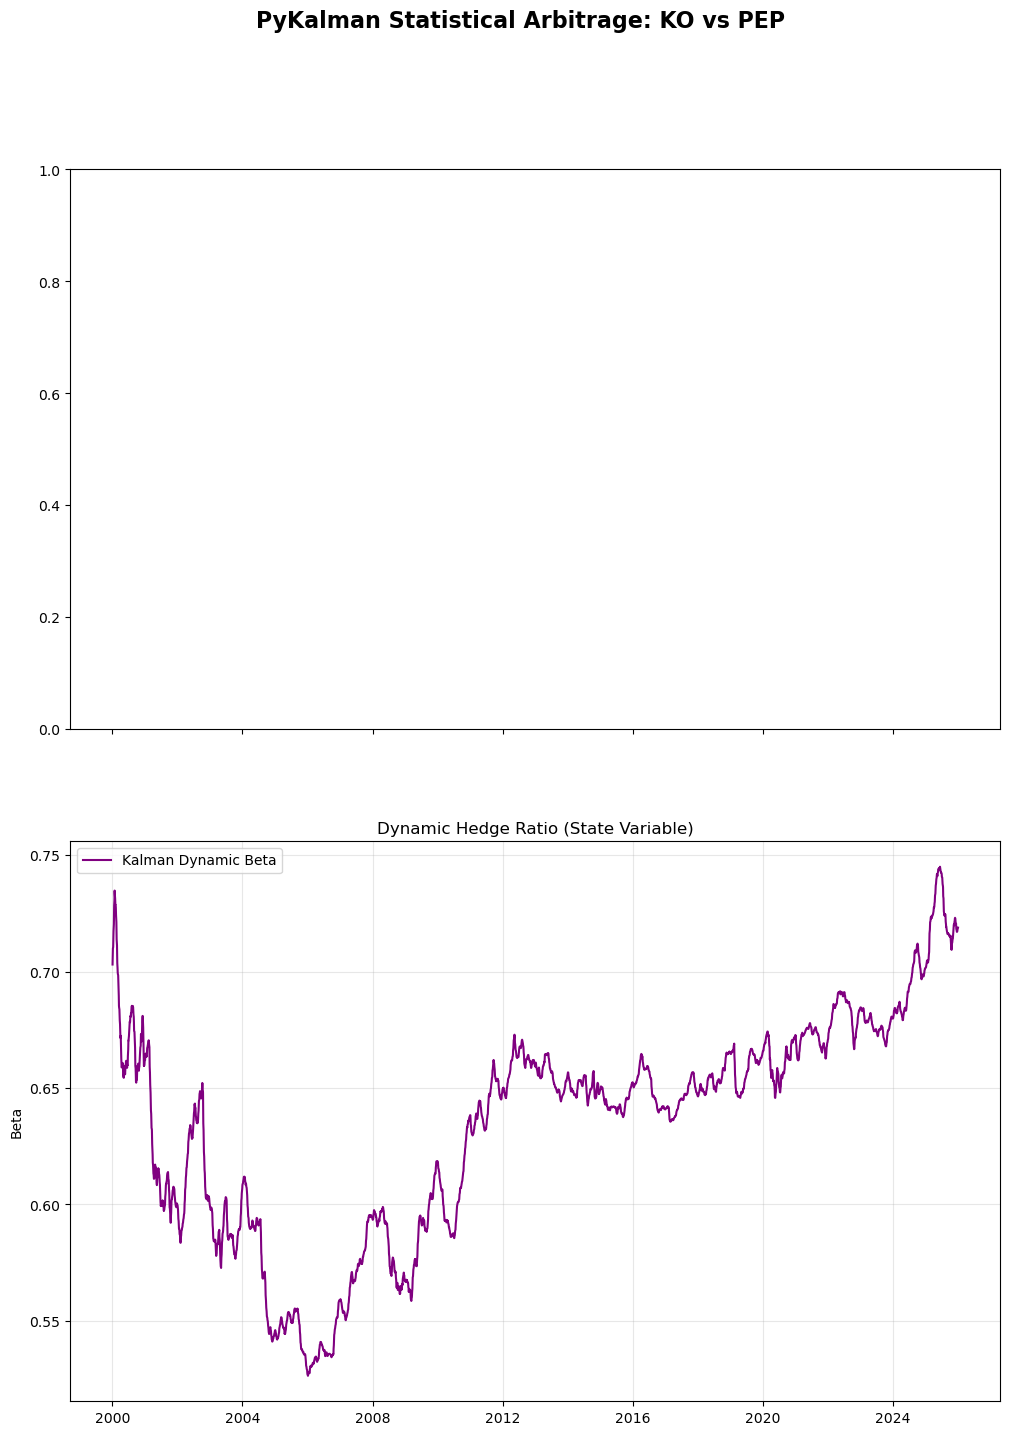

In [ ]:
import matplotlib.pyplot as plt

print("Generating performance tear sheet...")

# Create a 2-panel subplot figure
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
fig.suptitle('PyKalman Statistical Arbitrage: KO vs PEP', fontsize=16, fontweight='bold')

# --- Panel 1: Z-Score Spread ---
axs[0].plot(data['Native_Z_Score'], color='blue', label='Z-Score (Spread)')
axs[0].axhline(y=1.0, color='green', linestyle='--', alpha=0.7, label='Entry Threshold')
axs[0].axhline(y=-1.0, color='red', linestyle='--', alpha=0.7)
axs[0].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axs[0].set_title('Z-Score of Spread (Kalman Filter)')
axs[0].set_ylabel('Z-Score')
axs[0].legend(loc='upper left')
axs[0].grid(True, alpha=0.3)

# --- Panel 2: Dynamic Hedge Ratio (Beta) ---
axs[1].plot(data['beta'], color='purple', label='Kalman Dynamic Beta')
axs[1].set_title('Dynamic Hedge Ratio (State Variable)')
axs[1].set_ylabel('Beta')
axs[1].set_xlabel('Date')
axs[1].legend(loc='upper left')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.95) # Adjust title spacing
plt.show()

# --- Panel 3: Strategy Equity Curve vs. Benchmark (separate figure) ---
fig2, ax = plt.subplots(figsize=(12, 6))
benchmark_cum = (1 + data['Ret_KO'].fillna(0)).cumprod()

ax.plot(data['Levered_Equity_Curve'], color='green', linewidth=2, label='Zero-Beta Strategy')
ax.plot(benchmark_cum, color='gray', linestyle='--', label='Benchmark (Long KO)')
ax.set_title('Cumulative Equity Curve: Strategy vs Benchmark')
ax.set_ylabel('Cumulative Return')
ax.set_xlabel('Date')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()